In [1]:
from __future__ import print_function, division

import torch
import torch.optim as optim

from torch.optim import lr_scheduler
from torchvision import datasets, transforms
import time
import os

import torch.nn as nn


In [2]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            
            # Layer 1: 2048 Neurons
            nn.Linear(32 * 32 * 1, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            # Layer 2: 1024 Neurons
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Layer 3: 512 Neurons
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            
            # Output Layer
            nn.Linear(512, 10)
        )
        
    def forward(self, xb):
        return self.network(xb)

In [3]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),  
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.Resize((32,32)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((32,32)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]),
}

In [4]:
def train_test(model, criterion, optimizer, scheduler, num_epochs):
    train_loss = []
    train_accuracy = []
    history = dict()
    model.train()
    
    total_start_time = time.time() 

    for epoch in range(num_epochs):
        running_training_loss = 0.0
        running_training_accuracy = 0.0
        total_training_predictions = 0
       
        start_time = time.time()
        for i, data in enumerate(train_dataloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_training_loss += loss.item()*inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_training_predictions += labels.size(0)
            running_training_accuracy += (predicted == labels).sum().item()

        end_time = time.time()
        epoch_training_accuracy = running_training_accuracy / train_size*100
        epoch_training_loss = running_training_loss / train_size
        
        print(f'Epoch:[{epoch + 1}], Accuracy: {epoch_training_accuracy:.1f}%, Loss: {epoch_training_loss:.3f}, Time: {end_time-start_time:.1f}s')
        
        train_loss.append(epoch_training_loss)
        train_accuracy.append(epoch_training_accuracy)
        scheduler.step()
        
    print('Finished Training')

    # --- PER-CLASS ACCURACY SECTION ---
    correct_pred = {str(i): 0 for i in range(10)}
    total_pred = {str(i): 0 for i in range(10)}

    model.eval()
    with torch.no_grad():
        for data in test_dataloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[str(label.item())] += 1
                total_pred[str(label.item())] += 1

    print('\nAccuracy per class:')
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Class {classname:5s}: {accuracy:.1f} %')

    overall_accuracy = 100 * sum(correct_pred.values()) / sum(total_pred.values())
    total_duration = time.time() - total_start_time
    print(f'\nOverall Test Accuracy: {overall_accuracy:.1f} %')
    print(f'Total Program Time: {total_duration/60:.2f} minutes') 
    
    return history, overall_accuracy

In [ ]:
if __name__ == '__main__':
    data_dir = './data'    
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                            data_transforms[x])
                    for x in ['train', 'test']}

    train_dataloader = torch.utils.data.DataLoader(image_datasets['train'], batch_size=128,
                                                shuffle=True, num_workers=4)

    test_dataloader = torch.utils.data.DataLoader(image_datasets['test'], batch_size=128,
                                                shuffle=False, num_workers=4)

    train_size = len(image_datasets['train'])
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    model_ft = Net().to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.0005)  

    exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=10, gamma=0.7)
    
    history, accuracy = train_test(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
               num_epochs=40)

Epoch:[1], Accuracy: 17.9%, Loss: 2.226, Time: 23.6s
Epoch:[2], Accuracy: 35.2%, Loss: 1.863, Time: 23.3s
Epoch:[3], Accuracy: 44.4%, Loss: 1.641, Time: 26.3s
Epoch:[4], Accuracy: 49.5%, Loss: 1.505, Time: 28.2s
Epoch:[5], Accuracy: 53.3%, Loss: 1.409, Time: 23.4s
Epoch:[6], Accuracy: 55.8%, Loss: 1.340, Time: 23.3s
Epoch:[7], Accuracy: 57.8%, Loss: 1.282, Time: 22.3s
Epoch:[8], Accuracy: 59.4%, Loss: 1.231, Time: 24.8s
Epoch:[9], Accuracy: 61.2%, Loss: 1.191, Time: 25.4s
Epoch:[10], Accuracy: 62.3%, Loss: 1.159, Time: 24.0s
Epoch:[11], Accuracy: 64.4%, Loss: 1.102, Time: 23.6s
Epoch:[12], Accuracy: 65.4%, Loss: 1.070, Time: 24.8s
Epoch:[13], Accuracy: 66.0%, Loss: 1.054, Time: 23.3s
Epoch:[14], Accuracy: 66.8%, Loss: 1.029, Time: 23.7s
Epoch:[15], Accuracy: 67.0%, Loss: 1.022, Time: 22.2s
Epoch:[16], Accuracy: 67.5%, Loss: 1.008, Time: 22.2s
Epoch:[17], Accuracy: 68.2%, Loss: 0.986, Time: 22.4s
Epoch:[18], Accuracy: 68.4%, Loss: 0.975, Time: 22.2s
Epoch:[19], Accuracy: 68.4%, Loss: 0.

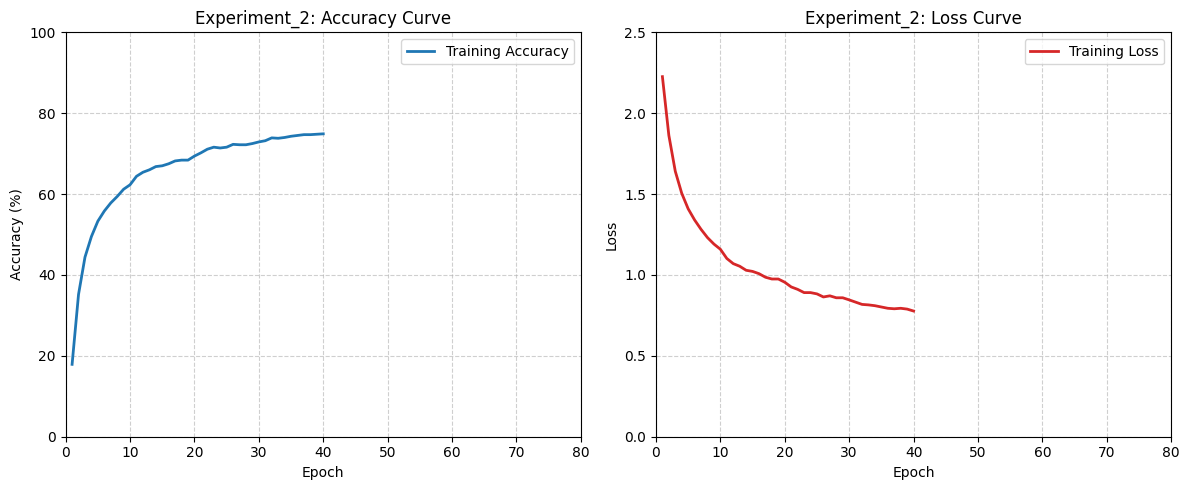

In [ ]:
import matplotlib.pyplot as plt
import re

def plot_from_log(file_name, exp_name):
    epochs, accs, losses = [], [], []
    
    with open(file_name, 'r') as f:
        content = f.read()
    
    pattern = r"Epoch:?\[(\d+)\],?\s*Accuracy:?\s*([\d.]+)%,?\s*Loss:?\s*([\d.]+)"
    matches = re.findall(pattern, content)
    
    for m in matches:
        epochs.append(int(m[0]))
        accs.append(float(m[1]))
        losses.append(float(m[2]))

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, accs, label='Training Accuracy', color='#1f77b4', linewidth=2)
    plt.title(f'{exp_name}: Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    
    plt.xlim(0, 80)
    plt.ylim(0, 100)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, losses, label='Training Loss', color='#d62728', linewidth=2)
    plt.title(f'{exp_name}: Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.xlim(0, 80)
    plt.ylim(0, 2.5) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{exp_name}_standardized_curves.png', dpi=300) 
    plt.show()

plot_from_log('02_scaling_model_capacity_log.txt', '02_scaling_model_capacity')